In [38]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, GridSearchCV

features = pd.read_csv('../dataset_for_modeling/features_for_ranking.csv')
players = pd.read_csv('../dataset_cleaned/players_teams.csv')

features.head(20)

,tmID,year,rank,franchID,confID,player_awards,net_rating,off_eff,def_eff,home_win_pct,...,blk_dif,pf_dif,coach_awards,efg_pct,win_pct,pts_per_poss,ts_pct,eff_x_pace,net_four_factors,pyth_wins
0,ATL,9,7,ATL,EA,0,-10.147059,1.122232,1.277285,0.058824,...,8,70,0,0.457693,0.117647,0.932715,0.491657,-12.363185,-0.035973,0.144856
1,ATL,10,2,ATL,EA,1,1.882353,1.178336,1.183665,0.705882,...,-12,41,1,0.498173,0.529412,1.011543,0.518260,-0.444778,0.010384,0.578031
2,CHA,1,8,CHA,EA,0,-7.593750,1.148713,1.258549,0.312500,...,-33,117,0,0.479414,0.250000,0.969847,0.506750,-7.731820,-0.021991,0.187521
3,CHA,2,4,CHA,EA,0,1.437500,1.154494,1.088299,0.687500,...,-10,26,0,0.478436,0.562500,0.983147,0.510605,4.342680,0.005765,0.578082
4,CHA,3,2,CHA,EA,0,3.375000,1.251955,1.180410,0.687500,...,2,47,0,0.493624,0.562500,1.067036,0.538257,4.707899,0.006568,0.665311
5,CHA,4,2,CHA,EA,0,0.647059,1.178628,1.154048,0.764706,...,11,91,0,0.478581,0.529412,1.006001,0.517845,1.587261,0.003116,0.534625
6,CHA,5,5,CHA,EA,0,-2.235294,1.199541,1.122153,0.588235,...,20,53,0,0.482277,0.470588,0.978697,0.522060,4.900992,-0.022493,0.378394
7,CHA,6,6,CHA,EA,0,-7.058824,1.095139,1.236758,0.294118,...,-33,73,0,0.466173,0.176471,0.906810,0.478844,-9.571403,-0.026841,0.181138
8,CHA,7,6,CHA,EA,0,-3.382353,1.127640,1.196370,0.411765,...,30,27,0,0.454987,0.323529,0.931360,0.487325,-5.329841,-0.025034,0.346030
9,CHI,7,7,CHI,EA,0,-10.735294,1.067586,1.251514,0.176471,...,5,90,0,0.436494,0.147059,0.920405,0.472351,-13.644636,-0.045043,0.116006


def_eff             0.557654
pf_dif              0.305900
year               -0.119087
coach_awards       -0.314351
blk_dif            -0.367617
reb_dif            -0.424061
player_awards      -0.455101
off_eff            -0.497779
efg_pct            -0.505535
ts_pct             -0.513849
pts_per_poss       -0.564497
ast_dif            -0.575608
eff_x_pace         -0.700264
net_four_factors   -0.717112
away_win_pct       -0.765164
home_win_pct       -0.792679
net_rating         -0.810810
pyth_wins          -0.831929
conf_win_pct       -0.868701
win_pct            -0.887239
Name: rank, dtype: float64


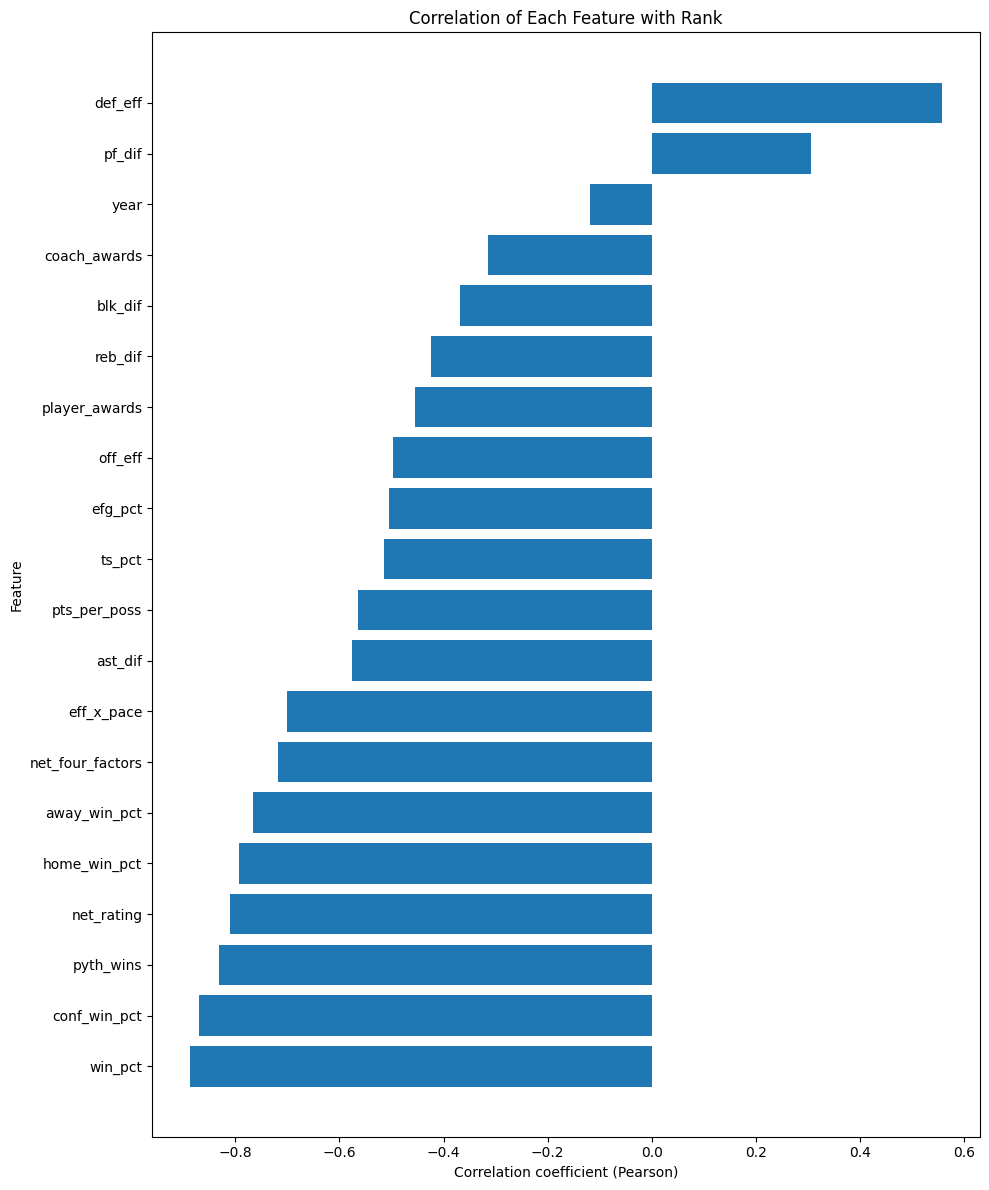

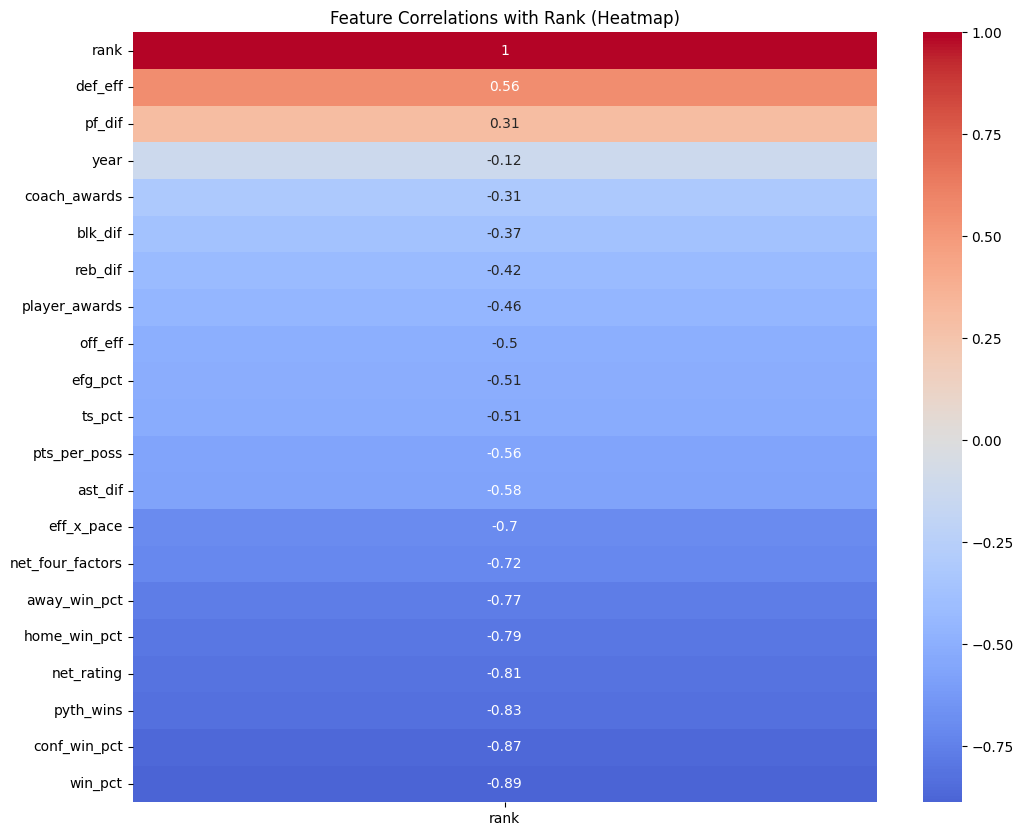

In [39]:
numeric_features = features.select_dtypes(include=['number'])
correlation = numeric_features.corr()['rank'].drop('rank').sort_values(ascending=False)

print(correlation)

plt.figure(figsize=(10, 12))
plt.barh(correlation.index, correlation.values)
plt.title("Correlation of Each Feature with Rank")
plt.xlabel("Correlation coefficient (Pearson)")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_features.corr()[['rank']].sort_values(by='rank', ascending=False), 
            annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlations with Rank (Heatmap)")
plt.show()

In [40]:
# Calcular % de jogadores que permanecem na equipa
def calculate_roster_continuity(players_df):
    """
    Mede quantos jogadores de year N continuam em year N+1
    """
    # Jogadores ativos (minutos > 0)
    active_players = players_df[players_df['minutes'] > 100].copy()
    
    roster_continuity = []
    
    for team in active_players['tmID'].unique():
        for year in range(2, 11):  # anos 2-10
            current_roster = set(active_players[
                (active_players['tmID'] == team) & 
                (active_players['year'] == year - 1)
            ]['playerID'])
            
            next_roster = set(active_players[
                (active_players['tmID'] == team) & 
                (active_players['year'] == year)
            ]['playerID'])
            
            if len(current_roster) > 0:
                retention = len(current_roster & next_roster) / len(current_roster)
            else:
                retention = 0
            
            roster_continuity.append({
                'tmID': team,
                'year': year,
                'roster_retention_rate': retention
            })
    
    return pd.DataFrame(roster_continuity)


In [41]:
def calculate_minutes_concentration(players_df):
    """
    Mede se a equipa depende de poucas estrelas ou tem distribuição equilibrada
    """
    team_concentration = players_df.groupby(['tmID', 'year']).apply(
        lambda x: (x['minutes'].nlargest(3).sum() / x['minutes'].sum()) 
        if x['minutes'].sum() > 0 else 0
    ).reset_index(name='top3_minutes_pct')
    
    return team_concentration


In [42]:
def calculate_team_experience(players_df):
    """
    Anos médios de experiência dos jogadores
    """
    # Primeiro ano de cada jogador
    player_start_year = players_df.groupby('playerID')['year'].min()
    
    team_exp = []
    
    for team in players_df['tmID'].unique():
        for year in players_df['year'].unique():
            team_players = players_df[
                (players_df['tmID'] == team) & 
                (players_df['year'] == year) &
                (players_df['minutes'] > 100)  # jogadores regulares
            ]
            
            if len(team_players) > 0:
                # Experiência = ano atual - ano de estreia
                experience = team_players['playerID'].map(
                    lambda p: year - player_start_year[p]
                ).mean()
            else:
                experience = 0
            
            team_exp.append({
                'tmID': team,
                'year': year,
                'avg_player_experience': experience
            })
    
    return pd.DataFrame(team_exp)


In [43]:
def calculate_minutes_concentration(players_df):
    """
    Mede se a equipa depende de poucas estrelas ou tem distribuição equilibrada
    """
    team_concentration = players_df.groupby(['tmID', 'year']).apply(
        lambda x: (x['minutes'].nlargest(3).sum() / x['minutes'].sum()) 
        if x['minutes'].sum() > 0 else 0
    ).reset_index(name='top3_minutes_pct')
    
    return team_concentration


In [44]:
def calculate_player_momentum(players_df):
    """
    Média ponderada das performances dos jogadores nos últimos anos
    """
    # Performance individual por 36 minutos (normalizado)
    players_df['pts_per36'] = (players_df['points'] / players_df['minutes']) * 36
    players_df['reb_per36'] = (players_df['rebounds'] / players_df['minutes']) * 36
    players_df['ast_per36'] = (players_df['assists'] / players_df['minutes']) * 36
    
    # Para cada equipa, calcular média ponderada pelo histórico dos jogadores
    team_momentum = []
    
    for team in players_df['tmID'].unique():
        for year in range(2, 11):
            current_players = players_df[
                (players_df['tmID'] == team) & 
                (players_df['year'] == year)
            ]['playerID'].unique()
            
            # Desempenho desses jogadores no ano anterior
            prev_performance = players_df[
                (players_df['playerID'].isin(current_players)) &
                (players_df['year'] == year - 1)
            ]
            
            if len(prev_performance) > 0:
                weighted_pts = (prev_performance['pts_per36'] * prev_performance['minutes']).sum() / prev_performance['minutes'].sum()
            else:
                weighted_pts = 0
            
            team_momentum.append({
                'tmID': team,
                'year': year,
                'roster_prev_pts_per36': weighted_pts
            })
    
    return pd.DataFrame(team_momentum)


In [45]:
def aggregate_player_stats(players_df):
    """
    Agregar estatísticas individuais por equipa
    """
    team_stats = players_df.groupby(['tmID', 'year']).agg({
        'points': 'sum',
        'rebounds': 'sum',
        'assists': 'sum',
        'steals': 'sum',
        'blocks': 'sum',
        'turnovers': 'sum',
        'minutes': 'sum',
        'playerID': 'count'  # número de jogadores
    }).reset_index()
    
    # Eficiências por minuto
    team_stats['pts_per_minute'] = team_stats['points'] / team_stats['minutes']
    team_stats['ast_per_minute'] = team_stats['assists'] / team_stats['minutes']
    team_stats['to_per_minute'] = team_stats['turnovers'] / team_stats['minutes']
    
    team_stats = team_stats.rename(columns={'playerID': 'roster_size'})
    
    return team_stats


# Create Player-based Features

In [46]:
print("Creating player-based features...")
roster_continuity = calculate_roster_continuity(players)
team_experience = calculate_team_experience(players)
minutes_concentration = calculate_minutes_concentration(players)
player_stats = aggregate_player_stats(players)
player_momentum = calculate_player_momentum(players)

print(f"  - Roster continuity: {len(roster_continuity)} rows")
print(f"  - Team experience: {len(team_experience)} rows")
print(f"  - Minutes concentration: {len(minutes_concentration)} rows")
print(f"  - Player stats: {len(player_stats)} rows")
print(f"  - Player momentum: {len(player_momentum)} rows")

Creating player-based features...
  - Roster continuity: 180 rows
  - Team experience: 200 rows
  - Minutes concentration: 142 rows
  - Player stats: 142 rows
  - Player momentum: 180 rows


/tmp/ipykernel_8693/2679961840.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_concentration = players_df.groupby(['tmID', 'year']).apply(


# Merge Player Features With Existing Features

In [47]:
features_enhanced = features.copy()

# Merge all player-based features
features_enhanced = features_enhanced.merge(roster_continuity, on=['tmID', 'year'], how='left')
features_enhanced = features_enhanced.merge(team_experience, on=['tmID', 'year'], how='left')
features_enhanced = features_enhanced.merge(minutes_concentration, on=['tmID', 'year'], how='left')
features_enhanced = features_enhanced.merge(player_stats, on=['tmID', 'year'], how='left')
features_enhanced = features_enhanced.merge(player_momentum, on=['tmID', 'year'], how='left')

# Fill NaN values with 0 (for teams without data)
features_enhanced = features_enhanced.fillna(0)

print(f"\nOriginal features: {len(features.columns)} columns")
print(f"Enhanced features: {len(features_enhanced.columns)} columns")
print(f"New player-based features added: {len(features_enhanced.columns) - len(features.columns)}")


Original features: 24 columns
Enhanced features: 39 columns
New player-based features added: 15


# Add Previous Rank as Feature 

In [48]:
# Add previous rank - the most important predictor
features_enhanced['prev_rank'] = features_enhanced.groupby('tmID')['rank'].shift(1)

# Create target: next year's rank
features_enhanced['target_rank'] = features_enhanced.groupby('tmID')['rank'].shift(-1)

# Remove rows without complete data
features_complete = features_enhanced.dropna(subset=['target_rank', 'prev_rank'])

print(f"\nComplete data with lag features: {len(features_complete)} rows")

# Define features (now including player-based features AND prev_rank)
metadata_cols = ['tmID', 'year', 'rank', 'franchID', 'confID', 'target_rank']
feature_cols = [col for col in features_complete.columns if col not in metadata_cols]

print(f"Total features for modeling: {len(feature_cols)}")

# Check if prev_rank is included
if 'prev_rank' in feature_cols:
    print("✓ prev_rank is included in features")
else:
    print("⚠️  WARNING: prev_rank is missing!")


Complete data with lag features: 102 rows
Total features for modeling: 35
✓ prev_rank is included in features


# Check Dataset Statistics

In [49]:
print("\n" + "="*60)
print("DATASET STATISTICS")
print("="*60)

teams_per_year = features_complete.groupby('year')['tmID'].nunique()
print("\nTeams per year:")
print(teams_per_year.to_string())

print(f"\nTotal unique teams: {features_complete['tmID'].nunique()}")
print(f"Year range: {features_complete['year'].min()} to {features_complete['year'].max()}")


DATASET STATISTICS

Teams per year:
year
2    16
3    12
4    11
5    13
6    13
7    12
8    13
9    12

Total unique teams: 19
Year range: 2 to 9


# Single Holdout Test (Year 9 → Year 10)

In [50]:
# Split: train on years < 9, test on year 9 (to predict year 10)
train = features_complete[features_complete['year'] < 9]
test = features_complete[features_complete['year'] == 9]

x_train = train[feature_cols]
y_train = train['target_rank']
x_test = test[feature_cols]
y_test = test['target_rank']

print(f"\nTraining samples: {len(x_train)} (years {train['year'].min()}-{train['year'].max()})")
print(f"Test samples: {len(x_test)} (year 9 → predicting year 10)")

# Train model
print("\nTraining Random Forest model...")
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

# Make predictions
y_pred = model.predict(x_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Naive baseline
naive_predictions = test['rank'].values  # Current year 9 rank
naive_mae = mean_absolute_error(y_test, naive_predictions)
naive_r2 = r2_score(y_test, naive_predictions)

print(f"\n{'='*60}")
print("RESULTS: SINGLE HOLDOUT TEST")
print(f"{'='*60}")
print(f"\nModel Performance:")
print(f"  MAE: {mae:.2f}")
print(f"  R²: {r2:.2f}")

print(f"\nNaive Baseline (rank stays same):")
print(f"  MAE: {naive_mae:.2f}")
print(f"  R²: {naive_r2:.2f}")

print(f"\nImprovement over baseline:")
print(f"  MAE difference: {naive_mae - mae:.2f}")
print(f"  R² difference: {r2 - naive_r2:.2f}")

if mae < naive_mae:
    improvement_pct = ((naive_mae - mae) / naive_mae * 100)
    print(f"\n✓ Model is {improvement_pct:.1f}% better than baseline!")
else:
    print(f"\n⚠️  WARNING: Model is WORSE than naive baseline by {mae - naive_mae:.2f} MAE")

# Create comparison DataFrame
comparison = pd.DataFrame({
    'tmID': test['tmID'].values,
    'year_features': 9,
    'year_predicted': 10,
    'actual_rank': y_test.values,
    'predicted_rank': y_pred,
    'naive_prediction': naive_predictions,
    'model_error': np.abs(y_test.values - y_pred),
    'naive_error': np.abs(y_test.values - naive_predictions)
}).sort_values(by='predicted_rank')

print("\nDetailed Predictions for Year 10:")
print(comparison.to_string(index=False))


Training samples: 90 (years 2-8)
Test samples: 12 (year 9 → predicting year 10)

Training Random Forest model...

RESULTS: SINGLE HOLDOUT TEST

Model Performance:
  MAE: 1.57
  R²: 0.04

Naive Baseline (rank stays same):
  MAE: 2.25
  R²: -1.12

Improvement over baseline:
  MAE difference: 0.68
  R² difference: 1.16

✓ Model is 30.1% better than baseline!

Detailed Predictions for Year 10:
tmID  year_features  year_predicted  actual_rank  predicted_rank  naive_prediction  model_error  naive_error
 SAS              9              10          4.0        2.969070                 1     1.030930          3.0
 DET              9              10          3.0        3.112797                 1     0.112797          2.0
 CON              9              10          6.0        3.124812                 2     2.875188          4.0
 LAS              9              10          3.0        3.185458                 3     0.185458          0.0
 PHO              9              10          1.0        3.600

# Time Series Cross-Validation

In [51]:
# Sort by year for proper time series split
features_complete = features_complete.sort_values(['year', 'tmID'])

X_all = features_complete[feature_cols]
y_all = features_complete['target_rank']
years_all = features_complete['year']

# Use TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
    X_train_fold = X_all.iloc[train_idx]
    y_train_fold = y_all.iloc[train_idx]
    X_test_fold = X_all.iloc[test_idx]
    y_test_fold = y_all.iloc[test_idx]
    
    test_years = years_all.iloc[test_idx].unique()
    train_years = years_all.iloc[train_idx].unique()
    
    # Get current ranks for naive baseline
    current_ranks = features_complete.iloc[test_idx]['rank'].values
    
    # Train model
    model_fold = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    model_fold.fit(X_train_fold, y_train_fold)
    
    # Predict
    y_pred_fold = model_fold.predict(X_test_fold)
    
    # Evaluate
    mae_fold = mean_absolute_error(y_test_fold, y_pred_fold)
    r2_fold = r2_score(y_test_fold, y_pred_fold)
    
    # Naive baseline
    naive_mae_fold = mean_absolute_error(y_test_fold, current_ranks)
    naive_r2_fold = r2_score(y_test_fold, current_ranks)
    
    cv_results.append({
        'fold': fold + 1,
        'train_years': f"{train_years.min()}-{train_years.max()}",
        'test_years': f"{test_years.min()}-{test_years.max()}",
        'n_train': len(y_train_fold),
        'n_test': len(y_test_fold),
        'mae': mae_fold,
        'r2': r2_fold,
        'naive_mae': naive_mae_fold,
        'naive_r2': naive_r2_fold,
        'improvement': naive_mae_fold - mae_fold
    })
    
    print(f"\nFold {fold + 1}:")
    print(f"  Train: years {train_years.min()}-{train_years.max()} ({len(y_train_fold)} samples)")
    print(f"  Test:  years {test_years.min()}-{test_years.max()} ({len(y_test_fold)} samples)")
    print(f"  Model    - MAE: {mae_fold:.2f}, R²: {r2_fold:.2f}")
    print(f"  Baseline - MAE: {naive_mae_fold:.2f}, R²: {naive_r2_fold:.2f}")
    print(f"  Improvement: {naive_mae_fold - mae_fold:+.2f} MAE")

# Summary statistics
cv_df = pd.DataFrame(cv_results)

print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY")
print("="*60)
print("\nAll Folds:")
print(cv_df.to_string(index=False))

print(f"\n{'='*60}")
print("AVERAGE PERFORMANCE ACROSS FOLDS")
print(f"{'='*60}")
print(f"\nModel Performance:")
print(f"  Average MAE: {cv_df['mae'].mean():.2f} ± {cv_df['mae'].std():.2f}")
print(f"  Average R²:  {cv_df['r2'].mean():.2f} ± {cv_df['r2'].std():.2f}")

print(f"\nNaive Baseline:")
print(f"  Average MAE: {cv_df['naive_mae'].mean():.2f} ± {cv_df['naive_mae'].std():.2f}")
print(f"  Average R²:  {cv_df['naive_r2'].mean():.2f} ± {cv_df['naive_r2'].std():.2f}")

print(f"\nImprovement over Baseline:")
print(f"  Average: {cv_df['improvement'].mean():.2f} ± {cv_df['improvement'].std():.2f} MAE")

if cv_df['improvement'].mean() > 0:
    print(f"\n✓ Model is consistently better than baseline!")
    print(f"  Wins: {(cv_df['improvement'] > 0).sum()}/{len(cv_df)} folds")
else:
    print(f"\n⚠️  Model does NOT consistently beat baseline")
    print(f"  Wins: {(cv_df['improvement'] > 0).sum()}/{len(cv_df)} folds")



Fold 1:
  Train: years 2-3 (17 samples)
  Test:  years 3-4 (17 samples)
  Model    - MAE: 1.76, R²: -0.03
  Baseline - MAE: 2.29, R²: -1.35
  Improvement: +0.53 MAE

Fold 2:
  Train: years 2-4 (34 samples)
  Test:  years 4-5 (17 samples)
  Model    - MAE: 1.48, R²: -0.06
  Baseline - MAE: 1.88, R²: -0.80
  Improvement: +0.40 MAE

Fold 3:
  Train: years 2-5 (51 samples)
  Test:  years 5-7 (17 samples)
  Model    - MAE: 1.34, R²: 0.35
  Baseline - MAE: 1.18, R²: 0.37
  Improvement: -0.17 MAE

Fold 4:
  Train: years 2-7 (68 samples)
  Test:  years 7-8 (17 samples)
  Model    - MAE: 1.61, R²: -0.08
  Baseline - MAE: 1.71, R²: -0.70
  Improvement: +0.09 MAE

Fold 5:
  Train: years 2-8 (85 samples)
  Test:  years 8-9 (17 samples)
  Model    - MAE: 1.76, R²: -0.09
  Baseline - MAE: 2.18, R²: -0.93
  Improvement: +0.42 MAE

CROSS-VALIDATION SUMMARY

All Folds:
 fold train_years test_years  n_train  n_test      mae        r2  naive_mae  naive_r2  improvement
    1         2-3        3-4       

# Leave One Year Out Cross-Validation

In [52]:
lyo_results = []

available_years = sorted(features_complete['year'].unique())
print(f"\nAvailable years for testing: {available_years}")

for test_year in available_years[1:-1]:  # Skip first and last year
    # Split
    train_lyo = features_complete[features_complete['year'] < test_year]
    test_lyo = features_complete[features_complete['year'] == test_year]
    
    if len(train_lyo) < 10 or len(test_lyo) == 0:
        continue
    
    X_train_lyo = train_lyo[feature_cols]
    y_train_lyo = train_lyo['target_rank']
    X_test_lyo = test_lyo[feature_cols]
    y_test_lyo = test_lyo['target_rank']
    
    # Train
    model_lyo = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    model_lyo.fit(X_train_lyo, y_train_lyo)
    
    # Predict
    y_pred_lyo = model_lyo.predict(X_test_lyo)
    
    # Evaluate
    mae_lyo = mean_absolute_error(y_test_lyo, y_pred_lyo)
    r2_lyo = r2_score(y_test_lyo, y_pred_lyo)
    
    # Baseline
    naive_pred_lyo = test_lyo['rank'].values
    naive_mae_lyo = mean_absolute_error(y_test_lyo, naive_pred_lyo)
    naive_r2_lyo = r2_score(y_test_lyo, naive_pred_lyo)
    
    lyo_results.append({
        'features_year': test_year,
        'predicting_year': test_year + 1,
        'n_train': len(y_train_lyo),
        'n_test': len(y_test_lyo),
        'mae': mae_lyo,
        'r2': r2_lyo,
        'naive_mae': naive_mae_lyo,
        'naive_r2': naive_r2_lyo,
        'improvement': naive_mae_lyo - mae_lyo
    })
    
    print(f"\nYear {test_year} → Predict Year {test_year + 1}:")
    print(f"  Train: {len(y_train_lyo)} samples")
    print(f"  Test:  {len(y_test_lyo)} samples")
    print(f"  Model MAE: {mae_lyo:.2f}, R²: {r2_lyo:.2f}")
    print(f"  Naive MAE: {naive_mae_lyo:.2f}, R²: {naive_r2_lyo:.2f}")
    print(f"  Improvement: {naive_mae_lyo - mae_lyo:+.2f}")

# Summary
if len(lyo_results) > 0:
    lyo_df = pd.DataFrame(lyo_results)
    
    print("\n" + "="*60)
    print("LEAVE-ONE-YEAR-OUT SUMMARY")
    print("="*60)
    print(lyo_df.to_string(index=False))
    
    print(f"\nAverage Model MAE: {lyo_df['mae'].mean():.2f} ± {lyo_df['mae'].std():.2f}")
    print(f"Average Model R²: {lyo_df['r2'].mean():.2f} ± {lyo_df['r2'].std():.2f}")
    print(f"Average Baseline MAE: {lyo_df['naive_mae'].mean():.2f} ± {lyo_df['naive_mae'].std():.2f}")
    print(f"Average Improvement: {lyo_df['improvement'].mean():.2f} ± {lyo_df['improvement'].std():.2f}")


Available years for testing: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Year 3 → Predict Year 4:
  Train: 16 samples
  Test:  12 samples
  Model MAE: 1.84, R²: -0.05
  Naive MAE: 2.33, R²: -1.47
  Improvement: +0.49

Year 4 → Predict Year 5:
  Train: 28 samples
  Test:  11 samples
  Model MAE: 1.19, R²: 0.13
  Naive MAE: 2.18, R²: -1.48
  Improvement: +0.99

Year 5 → Predict Year 6:
  Train: 39 samples
  Test:  13 samples
  Model MAE: 1.64, R²: 0.03
  Naive MAE: 1.54, R²: -0.21
  Improvement: -0.11

Year 6 → Predict Year 7:
  Train: 52 samples
  Test:  13 samples
  Model MAE: 1.40, R²: 0.35
  Naive MAE: 1.08, R²: 0.44
  Improvement: -0.32

Year 7 → Predict Year 8:
  Train: 65 samples
  Test:  12 samples
  Model MAE: 1.65, R²: -0.10
  Naive MAE: 2.00, R²: -1.00
  Improvement: +0.35

Year 8 → Predict Year 9:
  Train: 77 samples
  Test:  13 samples
  Model MAE: 1.68, R²: -0.07
  Naive MAE: 1.54, R²: -0.21
  Improvement: -0.14

# Feature Importance 

In [53]:
# Feature importance
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(importances.head(20).to_string(index=False))

# Show player-based features specifically
player_features = [f for f in feature_cols if 'roster' in f or 'retention' in f or 'experience' in f or 'top3' in f]
player_importance = importances[importances['feature'].isin(player_features)]

if len(player_importance) > 0:
    print("\n" + "="*60)
    print("PLAYER-BASED FEATURES IMPORTANCE")
    print("="*60)
    print(player_importance.to_string(index=False))

# Check prev_rank importance
if 'prev_rank' in importances['feature'].values:
    prev_rank_imp = importances[importances['feature'] == 'prev_rank'].iloc[0]
    print(f"\nprev_rank importance: {prev_rank_imp['importance']:.4f} (rank #{importances[importances['feature'] == 'prev_rank'].index[0] + 1})")


Top 20 Most Important Features:
         feature  importance
top3_minutes_pct    0.069450
       pyth_wins    0.067300
      net_rating    0.055689
         reb_dif    0.049801
  ast_per_minute    0.045502
         assists    0.044330
    pts_per_poss    0.040207
        rebounds    0.039897
net_four_factors    0.037691
    away_win_pct    0.034926
         ast_dif    0.034545
  pts_per_minute    0.029962
   to_per_minute    0.029426
    conf_win_pct    0.027174
         win_pct    0.024962
          steals    0.024454
         minutes    0.024189
          points    0.023905
          ts_pct    0.023313
       prev_rank    0.022179

PLAYER-BASED FEATURES IMPORTANCE
              feature  importance
     top3_minutes_pct    0.069450
roster_retention_rate    0.021797
avg_player_experience    0.021719
roster_prev_pts_per36    0.020685
          roster_size    0.007259

prev_rank importance: 0.0222 (rank #35)


# Visualizations

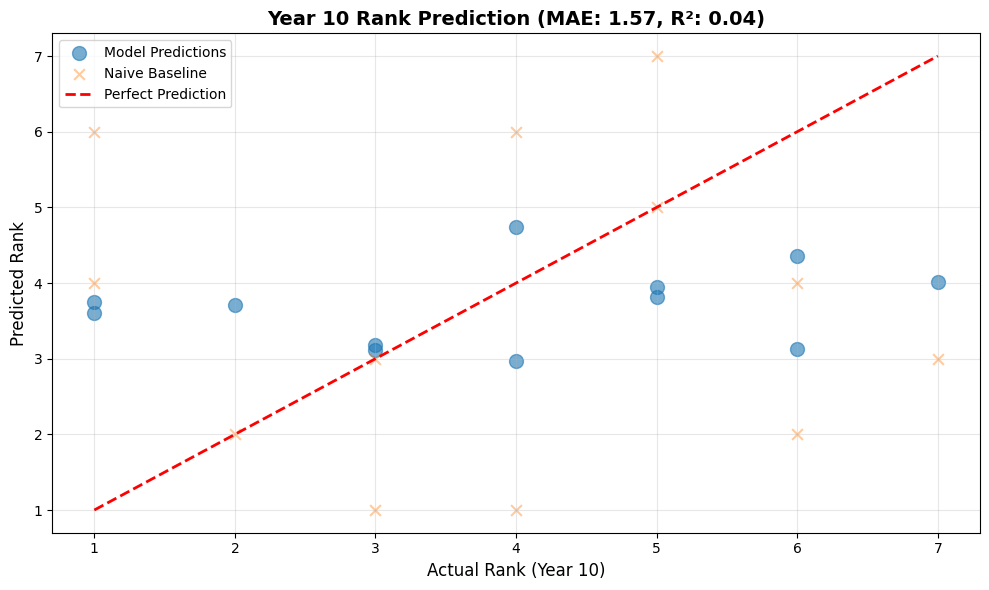

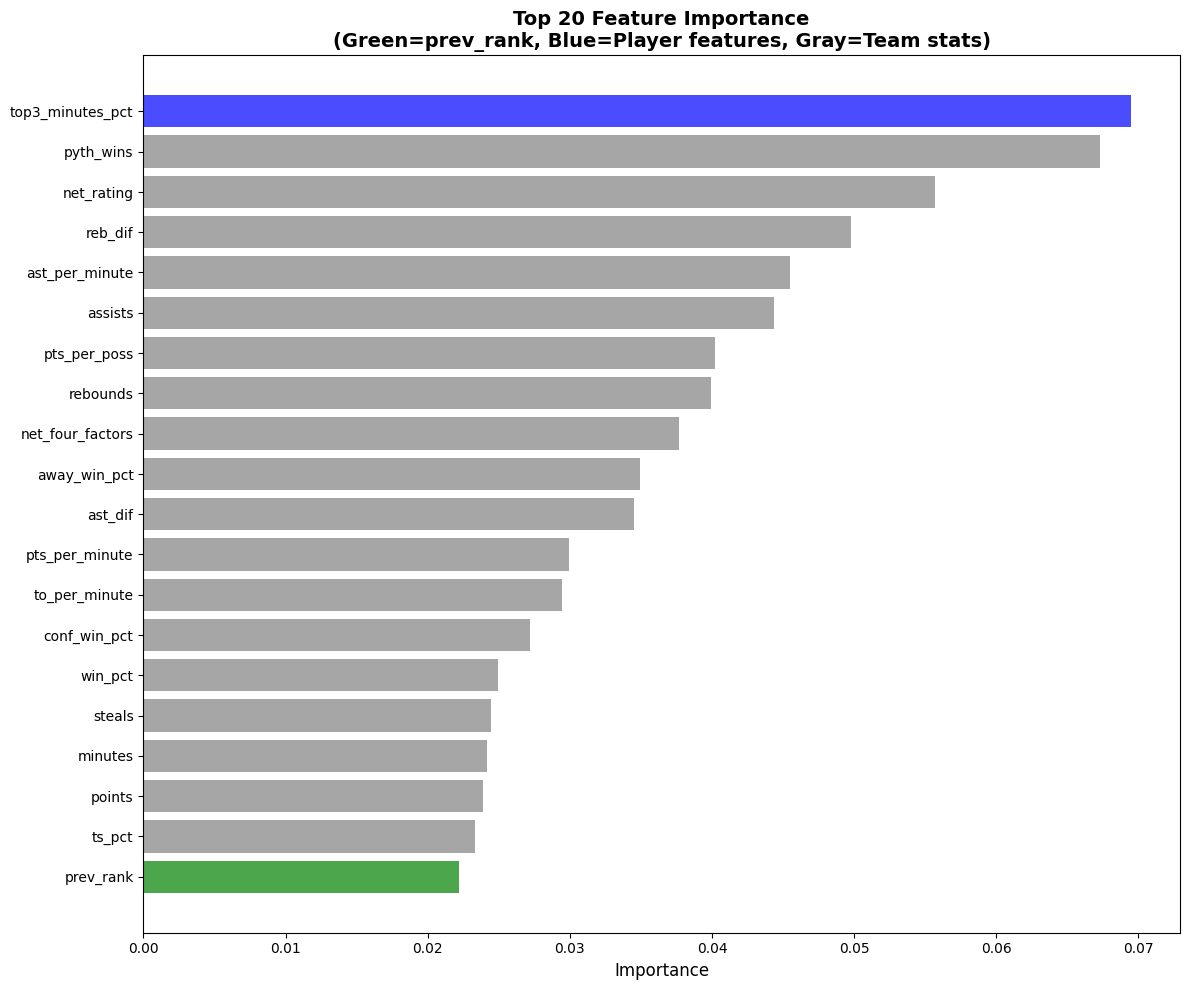

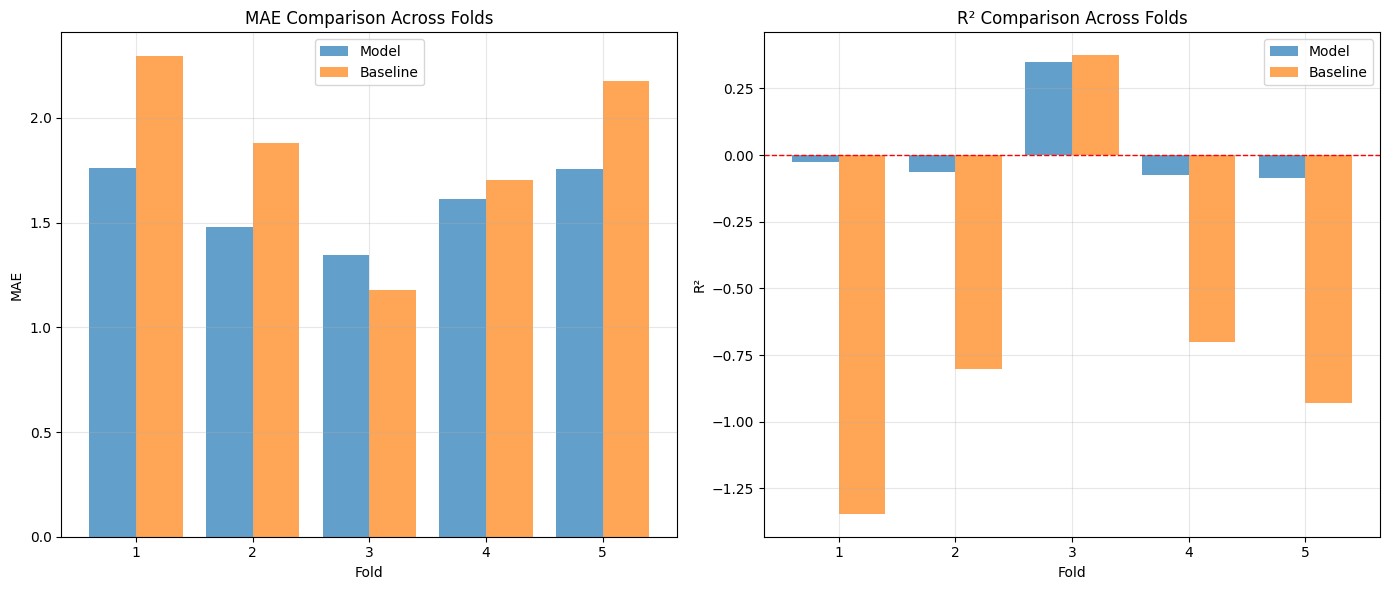


ANALYSIS COMPLETE!


In [54]:
# Predicted vs Actual (Single Holdout)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, s=100, label='Model Predictions')
plt.scatter(y_test, naive_predictions, alpha=0.4, s=60, label='Naive Baseline', marker='x')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Rank (Year 10)", fontsize=12)
plt.ylabel("Predicted Rank", fontsize=12)
plt.title(f"Year 10 Rank Prediction (MAE: {mae:.2f}, R²: {r2:.2f})", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance plot (top 20)
plt.figure(figsize=(12, 10))
top_features = importances.head(20)
colors = ['green' if f == 'prev_rank' else 'blue' if any(x in f for x in ['roster', 'retention', 'experience', 'top3']) else 'gray' 
          for f in top_features['feature']]
plt.barh(range(len(top_features)), top_features['importance'].values, color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel("Importance", fontsize=12)
plt.title("Top 20 Feature Importance\n(Green=prev_rank, Blue=Player features, Gray=Team stats)", 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Cross-validation results comparison
if len(cv_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # MAE comparison
    x_pos = np.arange(len(cv_df))
    axes[0].bar(x_pos - 0.2, cv_df['mae'], 0.4, label='Model', alpha=0.7)
    axes[0].bar(x_pos + 0.2, cv_df['naive_mae'], 0.4, label='Baseline', alpha=0.7)
    axes[0].set_xlabel('Fold')
    axes[0].set_ylabel('MAE')
    axes[0].set_title('MAE Comparison Across Folds')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(cv_df['fold'])
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # R² comparison
    axes[1].bar(x_pos - 0.2, cv_df['r2'], 0.4, label='Model', alpha=0.7)
    axes[1].bar(x_pos + 0.2, cv_df['naive_r2'], 0.4, label='Baseline', alpha=0.7)
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Fold')
    axes[1].set_ylabel('R²')
    axes[1].set_title('R² Comparison Across Folds')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(cv_df['fold'])
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)

# Compare Multiple Models

In [60]:
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
try:
    from xgboost import XGBRegressor
    xgboost_available = True
except ImportError:
    xgboost_available = False
    print("⚠️  XGBoost not available, skipping")

try:
    from lightgbm import LGBMRegressor
    lightgbm_available = True
except ImportError:
    lightgbm_available = False
    print("⚠️  LightGBM not available, skipping")

print("\n" + "="*60)
print("COMPARING MULTIPLE MODELS")
print("="*60)

# Define all models to compare
models_to_compare = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    'AdaBoost': AdaBoostRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    'Ridge Regression': Ridge(
        alpha=1.0,
        random_state=42
    ),
    'Lasso Regression': Lasso(
        alpha=0.1,
        random_state=42,
        max_iter=5000
    ),
    'ElasticNet': ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        random_state=42,
        max_iter=5000
    ),
    'KNN': KNeighborsRegressor(
        n_neighbors=5,
        weights='distance'
    ),
    'SVR': SVR(
        kernel='rbf',
        C=1.0,
        epsilon=0.1
    )
}

# Add XGBoost if available
if xgboost_available:
    models_to_compare['XGBoost'] = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

# Add LightGBM if available
if lightgbm_available:
    models_to_compare['LightGBM'] = LGBMRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )


COMPARING MULTIPLE MODELS


# Single Holdout Comparison

In [61]:
print("\n" + "="*60)
print("SINGLE HOLDOUT TEST - MODEL COMPARISON")
print("="*60)

holdout_results = []

for model_name, model_obj in models_to_compare.items():
    print(f"\nTraining {model_name}...")
    
    try:
        # Train
        model_obj.fit(x_train, y_train)
        
        # Predict
        y_pred_model = model_obj.predict(x_test)
        
        # Evaluate
        mae_model = mean_absolute_error(y_test, y_pred_model)
        r2_model = r2_score(y_test, y_pred_model)
        
        # Training performance
        y_train_pred_model = model_obj.predict(x_train)
        train_mae_model = mean_absolute_error(y_train, y_train_pred_model)
        train_r2_model = r2_score(y_train, y_train_pred_model)
        
        holdout_results.append({
            'model': model_name,
            'test_mae': mae_model,
            'test_r2': r2_model,
            'train_mae': train_mae_model,
            'train_r2': train_r2_model,
            'improvement_vs_baseline': naive_mae - mae_model,
            'overfit_gap': train_mae_model - mae_model
        })
        
        print(f"  Test MAE: {mae_model:.2f}, R²: {r2_model:.2f}")
        print(f"  Train MAE: {train_mae_model:.2f}, R²: {train_r2_model:.2f}")
        print(f"  Improvement over baseline: {naive_mae - mae_model:+.2f}")
        
    except Exception as e:
        print(f"  ❌ Failed: {str(e)}")

# Add baseline to results
holdout_results.append({
    'model': 'Naive Baseline',
    'test_mae': naive_mae,
    'test_r2': naive_r2,
    'train_mae': np.nan,
    'train_r2': np.nan,
    'improvement_vs_baseline': 0.0,
    'overfit_gap': np.nan
})

holdout_df = pd.DataFrame(holdout_results).sort_values('test_mae')

print("\n" + "="*60)
print("SINGLE HOLDOUT RESULTS SUMMARY")
print("="*60)
print(holdout_df.to_string(index=False))

print(f"\n🏆 Best Model: {holdout_df.iloc[0]['model']}")
print(f"   MAE: {holdout_df.iloc[0]['test_mae']:.2f}")
print(f"   R²: {holdout_df.iloc[0]['test_r2']:.2f}")
print(f"   Improvement over baseline: {holdout_df.iloc[0]['improvement_vs_baseline']:.2f}")


SINGLE HOLDOUT TEST - MODEL COMPARISON

Training Random Forest...
  Test MAE: 1.57, R²: 0.04
  Train MAE: 1.15, R²: 0.54
  Improvement over baseline: +0.68

Training Gradient Boosting...
  Test MAE: 1.31, R²: 0.34
  Train MAE: 0.02, R²: 1.00
  Improvement over baseline: +0.94

Training Extra Trees...
  Test MAE: 1.58, R²: 0.02
  Train MAE: 1.32, R²: 0.40
  Improvement over baseline: +0.67

Training AdaBoost...
  Test MAE: 1.58, R²: 0.01
  Train MAE: 0.88, R²: 0.74
  Improvement over baseline: +0.67

Training Ridge Regression...
  Test MAE: 1.57, R²: 0.07
  Train MAE: 1.34, R²: 0.35
  Improvement over baseline: +0.68

Training Lasso Regression...
  Test MAE: 1.64, R²: 0.01
  Train MAE: 1.39, R²: 0.30
  Improvement over baseline: +0.61

Training ElasticNet...
  Test MAE: 1.61, R²: 0.03
  Train MAE: 1.39, R²: 0.31
  Improvement over baseline: +0.64

Training KNN...
  Test MAE: 1.41, R²: 0.10
  Train MAE: 0.00, R²: 1.00
  Improvement over baseline: +0.84

Training SVR...
  Test MAE: 1.59,

# Time Series CV Comparison

In [62]:
tscv_model_results = []

for model_name, model_obj in models_to_compare.items():
    print(f"\nEvaluating {model_name} with Time Series CV...")
    
    fold_maes = []
    fold_r2s = []
    
    try:
        for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
            X_train_fold = X_all.iloc[train_idx]
            y_train_fold = y_all.iloc[train_idx]
            X_test_fold = X_all.iloc[test_idx]
            y_test_fold = y_all.iloc[test_idx]
            
            # Train
            model_obj.fit(X_train_fold, y_train_fold)
            
            # Predict
            y_pred_fold = model_obj.predict(X_test_fold)
            
            # Evaluate
            mae_fold = mean_absolute_error(y_test_fold, y_pred_fold)
            r2_fold = r2_score(y_test_fold, y_pred_fold)
            
            fold_maes.append(mae_fold)
            fold_r2s.append(r2_fold)
        
        avg_mae = np.mean(fold_maes)
        std_mae = np.std(fold_maes)
        avg_r2 = np.mean(fold_r2s)
        std_r2 = np.std(fold_r2s)
        
        tscv_model_results.append({
            'model': model_name,
            'avg_mae': avg_mae,
            'std_mae': std_mae,
            'avg_r2': avg_r2,
            'std_r2': std_r2,
            'improvement_vs_baseline': cv_df['naive_mae'].mean() - avg_mae
        })
        
        print(f"  Average MAE: {avg_mae:.2f} ± {std_mae:.2f}")
        print(f"  Average R²: {avg_r2:.2f} ± {std_r2:.2f}")
        
    except Exception as e:
        print(f"  ❌ Failed: {str(e)}")

# Add baseline
tscv_model_results.append({
    'model': 'Naive Baseline',
    'avg_mae': cv_df['naive_mae'].mean(),
    'std_mae': cv_df['naive_mae'].std(),
    'avg_r2': cv_df['naive_r2'].mean(),
    'std_r2': cv_df['naive_r2'].std(),
    'improvement_vs_baseline': 0.0
})

tscv_model_df = pd.DataFrame(tscv_model_results).sort_values('avg_mae')

print("\n" + "="*60)
print("TIME SERIES CV RESULTS SUMMARY")
print("="*60)
print(tscv_model_df.to_string(index=False))

print(f"\n🏆 Best Model (Time Series CV): {tscv_model_df.iloc[0]['model']}")
print(f"   Average MAE: {tscv_model_df.iloc[0]['avg_mae']:.2f} ± {tscv_model_df.iloc[0]['std_mae']:.2f}")
print(f"   Average R²: {tscv_model_df.iloc[0]['avg_r2']:.2f} ± {tscv_model_df.iloc[0]['std_r2']:.2f}")



Evaluating Random Forest with Time Series CV...
  Average MAE: 1.59 ± 0.16
  Average R²: 0.02 ± 0.17

Evaluating Gradient Boosting with Time Series CV...
  Average MAE: 1.69 ± 0.24
  Average R²: -0.17 ± 0.34

Evaluating Extra Trees with Time Series CV...
  Average MAE: 1.57 ± 0.15
  Average R²: 0.06 ± 0.15

Evaluating AdaBoost with Time Series CV...
  Average MAE: 1.59 ± 0.12
  Average R²: -0.08 ± 0.26

Evaluating Ridge Regression with Time Series CV...
  Average MAE: 3.01 ± 2.13
  Average R²: -4.21 ± 6.79

Evaluating Lasso Regression with Time Series CV...
  Average MAE: 3.27 ± 2.97
  Average R²: -6.14 ± 11.50

Evaluating ElasticNet with Time Series CV...
  Average MAE: 2.88 ± 2.13
  Average R²: -3.97 ± 7.01

Evaluating KNN with Time Series CV...
  Average MAE: 1.67 ± 0.09
  Average R²: -0.20 ± 0.24

Evaluating SVR with Time Series CV...
  Average MAE: 1.60 ± 0.08
  Average R²: -0.02 ± 0.03

Evaluating XGBoost with Time Series CV...
  Average MAE: 1.60 ± 0.16
  Average R²: -0.06 ± 0.

# Ensemble Methods

In [63]:

# Train all models on full training set
ensemble_predictions = {}

for model_name, model_obj in models_to_compare.items():
    try:
        model_obj.fit(x_train, y_train)
        ensemble_predictions[model_name] = model_obj.predict(x_test)
    except:
        pass

if len(ensemble_predictions) > 0:
    # Simple average ensemble
    ensemble_avg = np.mean(list(ensemble_predictions.values()), axis=0)
    ensemble_avg_mae = mean_absolute_error(y_test, ensemble_avg)
    ensemble_avg_r2 = r2_score(y_test, ensemble_avg)
    
    print(f"\nSimple Average Ensemble ({len(ensemble_predictions)} models):")
    print(f"  MAE: {ensemble_avg_mae:.2f}")
    print(f"  R²: {ensemble_avg_r2:.2f}")
    print(f"  Improvement over baseline: {naive_mae - ensemble_avg_mae:+.2f}")
    
    # Weighted ensemble (weight by inverse MAE from holdout)
    holdout_trained = holdout_df[holdout_df['model'] != 'Naive Baseline']
    weights = {}
    for _, row in holdout_trained.iterrows():
        if row['model'] in ensemble_predictions:
            # Weight = 1 / MAE (lower MAE = higher weight)
            weights[row['model']] = 1.0 / row['test_mae']
    
    # Normalize weights
    total_weight = sum(weights.values())
    weights = {k: v/total_weight for k, v in weights.items()}
    
    # Weighted prediction
    ensemble_weighted = np.zeros(len(y_test))
    for model_name, pred in ensemble_predictions.items():
        if model_name in weights:
            ensemble_weighted += weights[model_name] * pred
    
    ensemble_weighted_mae = mean_absolute_error(y_test, ensemble_weighted)
    ensemble_weighted_r2 = r2_score(y_test, ensemble_weighted)
    
    print(f"\nWeighted Ensemble (by inverse MAE):")
    print(f"  MAE: {ensemble_weighted_mae:.2f}")
    print(f"  R²: {ensemble_weighted_r2:.2f}")
    print(f"  Improvement over baseline: {naive_mae - ensemble_weighted_mae:+.2f}")
    
    print("\nWeights:")
    for model_name, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
        print(f"  {model_name}: {weight:.3f}")



Simple Average Ensemble (11 models):
  MAE: 1.46
  R²: 0.16
  Improvement over baseline: +0.79

Weighted Ensemble (by inverse MAE):
  MAE: 1.45
  R²: 0.17
  Improvement over baseline: +0.80

Weights:
  Gradient Boosting: 0.106
  KNN: 0.098
  LightGBM: 0.097
  XGBoost: 0.093
  Random Forest: 0.088
  Ridge Regression: 0.088
  Extra Trees: 0.087
  AdaBoost: 0.087
  SVR: 0.087
  ElasticNet: 0.086
  Lasso Regression: 0.084


# Additional Visualizations

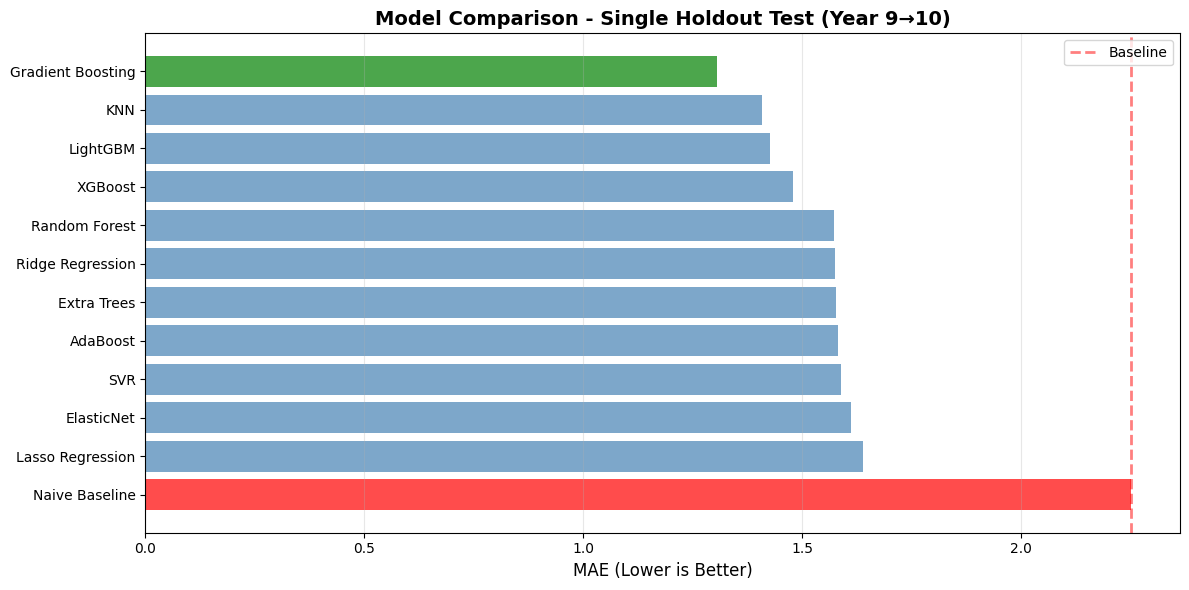

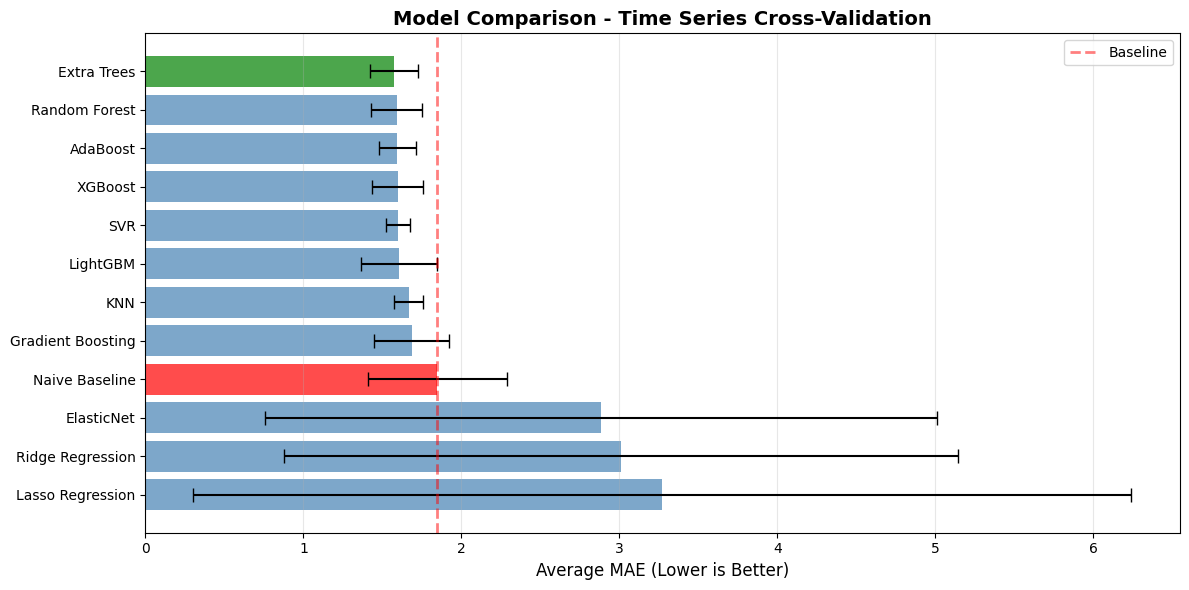

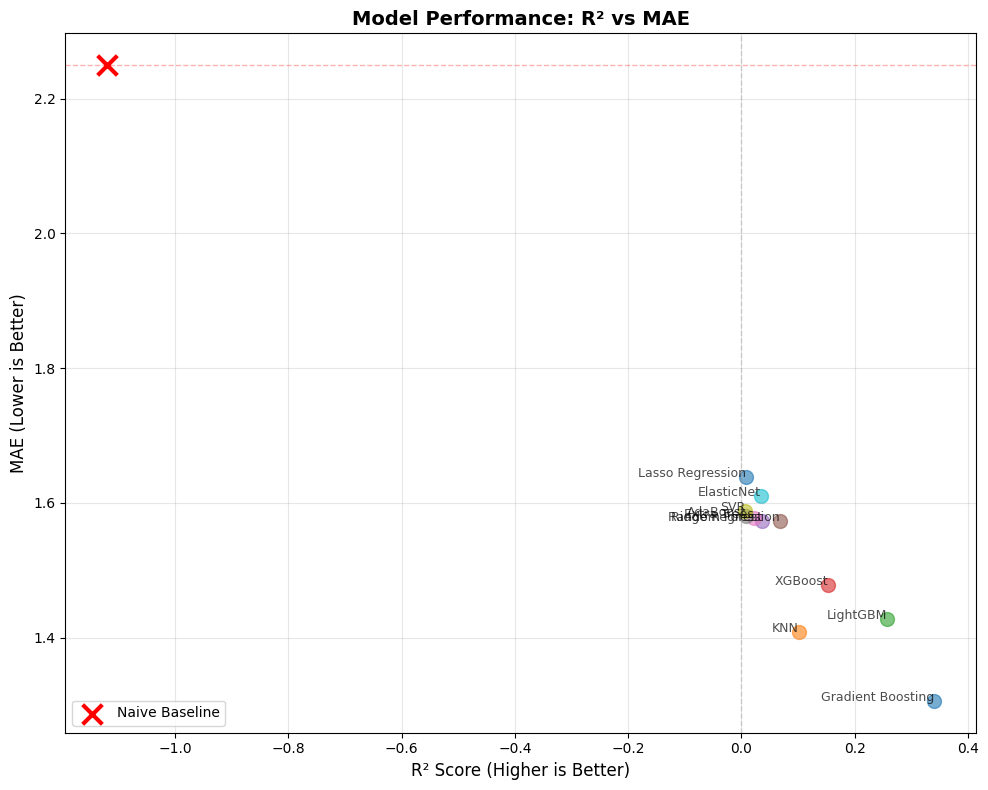

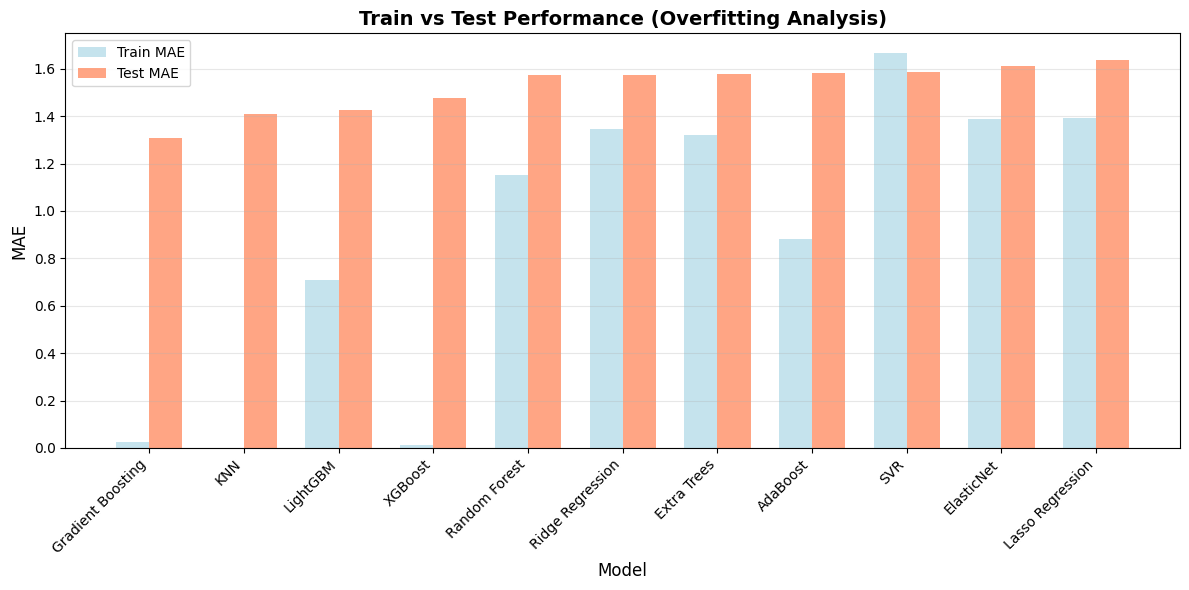


MODEL COMPARISON COMPLETE!

FINAL RECOMMENDATIONS

🏆 Best Single Holdout Model: Gradient Boosting
   Test MAE: 1.31
   Better than baseline by: 0.94 positions

🏆 Best Cross-Validated Model: Extra Trees
   Average MAE: 1.57 ± 0.15
   Better than baseline by: 0.27 positions

🎯 RECOMMENDATION: Use Extra Trees
   More robust across multiple time periods


In [64]:
# Model comparison bar chart (Holdout Test)
plt.figure(figsize=(12, 6))
holdout_sorted = holdout_df.sort_values('test_mae')
colors_bar = ['red' if m == 'Naive Baseline' else 'green' if i == 0 else 'steelblue' 
              for i, m in enumerate(holdout_sorted['model'])]
plt.barh(range(len(holdout_sorted)), holdout_sorted['test_mae'], color=colors_bar, alpha=0.7)
plt.yticks(range(len(holdout_sorted)), holdout_sorted['model'])
plt.xlabel('MAE (Lower is Better)', fontsize=12)
plt.title('Model Comparison - Single Holdout Test (Year 9→10)', fontsize=14, fontweight='bold')
plt.axvline(x=naive_mae, color='red', linestyle='--', linewidth=2, label='Baseline', alpha=0.5)
plt.legend()
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Time Series CV comparison
plt.figure(figsize=(12, 6))
tscv_sorted = tscv_model_df.sort_values('avg_mae')
colors_bar_cv = ['red' if m == 'Naive Baseline' else 'green' if i == 0 else 'steelblue' 
                 for i, m in enumerate(tscv_sorted['model'])]
plt.barh(range(len(tscv_sorted)), tscv_sorted['avg_mae'], 
         xerr=tscv_sorted['std_mae'], color=colors_bar_cv, alpha=0.7, capsize=5)
plt.yticks(range(len(tscv_sorted)), tscv_sorted['model'])
plt.xlabel('Average MAE (Lower is Better)', fontsize=12)
plt.title('Model Comparison - Time Series Cross-Validation', fontsize=14, fontweight='bold')
plt.axvline(x=cv_df['naive_mae'].mean(), color='red', linestyle='--', linewidth=2, label='Baseline', alpha=0.5)
plt.legend()
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# R² comparison scatter plot
if len(holdout_df) > 1:
    plt.figure(figsize=(10, 8))
    
    for _, row in holdout_df.iterrows():
        if row['model'] == 'Naive Baseline':
            plt.scatter(row['test_r2'], row['test_mae'], s=200, c='red', marker='x', 
                       label='Naive Baseline', linewidths=3, zorder=5)
        else:
            plt.scatter(row['test_r2'], row['test_mae'], s=100, alpha=0.6)
            plt.annotate(row['model'], (row['test_r2'], row['test_mae']), 
                        fontsize=9, ha='right', alpha=0.7)
    
    plt.xlabel('R² Score (Higher is Better)', fontsize=12)
    plt.ylabel('MAE (Lower is Better)', fontsize=12)
    plt.title('Model Performance: R² vs MAE', fontsize=14, fontweight='bold')
    plt.axhline(y=naive_mae, color='red', linestyle='--', alpha=0.3, linewidth=1)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3, linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Overfitting analysis
plt.figure(figsize=(12, 6))
holdout_with_train = holdout_df[holdout_df['model'] != 'Naive Baseline'].copy()
x_pos = np.arange(len(holdout_with_train))
width = 0.35

plt.bar(x_pos - width/2, holdout_with_train['train_mae'], width, 
        label='Train MAE', alpha=0.7, color='lightblue')
plt.bar(x_pos + width/2, holdout_with_train['test_mae'], width, 
        label='Test MAE', alpha=0.7, color='coral')

plt.xlabel('Model', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('Train vs Test Performance (Overfitting Analysis)', fontsize=14, fontweight='bold')
plt.xticks(x_pos, holdout_with_train['model'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("MODEL COMPARISON COMPLETE!")
print("="*60)

# Final summary
print("\n" + "="*60)
print("FINAL RECOMMENDATIONS")
print("="*60)

best_holdout = holdout_df[holdout_df['model'] != 'Naive Baseline'].iloc[0]
best_cv = tscv_model_df[tscv_model_df['model'] != 'Naive Baseline'].iloc[0]

print(f"\n🏆 Best Single Holdout Model: {best_holdout['model']}")
print(f"   Test MAE: {best_holdout['test_mae']:.2f}")
print(f"   Better than baseline by: {best_holdout['improvement_vs_baseline']:.2f} positions")

print(f"\n🏆 Best Cross-Validated Model: {best_cv['model']}")
print(f"   Average MAE: {best_cv['avg_mae']:.2f} ± {best_cv['std_mae']:.2f}")
print(f"   Better than baseline by: {best_cv['improvement_vs_baseline']:.2f} positions")

if ensemble_avg_mae < best_holdout['test_mae']:
    print(f"\n🎯 RECOMMENDATION: Use Ensemble Average")
    print(f"   MAE: {ensemble_avg_mae:.2f} (best overall)")
elif best_cv['model'] == best_holdout['model']:
    print(f"\n🎯 RECOMMENDATION: Use {best_cv['model']}")
    print(f"   Consistent winner in both holdout and CV")
else:
    print(f"\n🎯 RECOMMENDATION: Use {best_cv['model']}")
    print(f"   More robust across multiple time periods")
